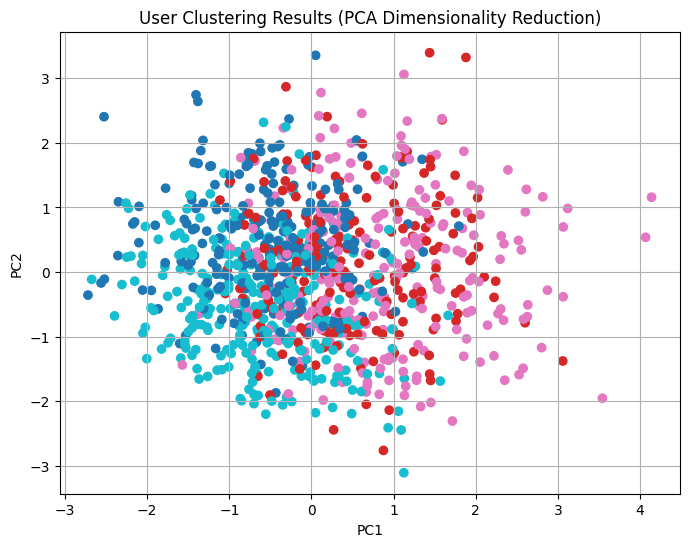

In [11]:
# 模拟项目，构造对应的数据
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 模拟 1000 个用户行为数据
np.random.seed(42)
data = pd.DataFrame({
    'view': np.random.poisson(20, 1000),
    'cart': np.random.poisson(5, 1000),
    'purchase': np.random.poisson(2, 1000),
    'return': np.random.poisson(0.3, 1000),
    'recency': np.random.randint(1, 100, 1000),
    'frequency': np.random.poisson(10, 1000),
    'monetary': np.random.gamma(100, 2, 1000),
})

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# KMeans 聚类
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# DBSCAN 聚类
# from sklearn.cluster import DBSCAN
# dbscan = DBSCAN(eps=1.5, min_samples=10)
# labels = dbscan.fit_predict(X_scaled)

# 用 PCA 降维后可视化
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10')
plt.title("User Clustering Results (PCA Dimensionality Reduction)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [3]:
data['cluster'] = labels
print(data.groupby('cluster').mean())

              view      cart  purchase    return    recency  frequency  \
cluster                                                                  
0        19.277344  3.941406  1.718750  0.015625  22.976562   9.722656   
1        21.833333  7.454545  2.702020  0.055556  46.525253  10.227273   
2        20.441767  4.730924  1.991968  1.184739  48.815261  10.401606   
3        18.646465  4.205387  1.828283  0.010101  74.427609  10.053872   

           monetary  
cluster              
0        195.138639  
1        201.423498  
2        201.407478  
3        200.777153  
